# Predicting jewelry prices from eBay listings

I scraped Fine Jewelry listings off eBay and I'm trying to predict asking price from brand, metal, condition, and whatever I can pull out of the title.

The raw file is `../data/ebay_fine_jewelry_listings_sample.csv`. It mixes an older Tiffany-only scrape with a later run of Tiffany, David Yurman, and Cartier (2 metals each, 1 search page per combo). That's why some columns are sparse and why there are duplicate listings.


## Load the scrape


In [19]:
%matplotlib inline

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/ebay_fine_jewelry_listings_sample.csv")
print(df.shape)
df.head()


(1535, 14)


,title,price,price_text,currency,price_usd,condition,metal_item_page,purity_item_page,weight_item_page,length_item_page,url,brand,metal,metal_url
0,Tiffany Co 18k Yellow Gold Elsa Peretti Diamon...,649.99,US $649.99,USD,649.99,Pre-owned - Good Pre-owned - Good More informa...,NaN,NaN,NaN,NaN,https://www.ebay.com/itm/116790370464?_skw=Tif...,Tiffany & Co.,Yellow Gold,https://www.ebay.com/b/Tiffany-Co/bn_21836959?...
1,Tiffany & Co. Bean Pendant Necklace 18k Yellow...,675.02,US $675.02,USD,675.02,Pre-owned - Excellent Pre-owned - Excellent Mo...,NaN,NaN,NaN,NaN,https://www.ebay.com/itm/285507690310?_skw=Tif...,Tiffany & Co.,Yellow Gold,https://www.ebay.com/b/Tiffany-Co/bn_21836959?...
2,Vintage Tiffany & Co 14K 585 Yellow Gold Ova...,699.99,US $699.99,USD,699.99,Pre-owned - Good Pre-owned - Good More informa...,NaN,NaN,NaN,NaN,https://www.ebay.com/itm/167807383338?_skw=Tif...,Tiffany & Co.,Yellow Gold,https://www.ebay.com/b/Tiffany-Co/bn_21836959?...
3,Tiffany & Co. 18K Yellow Gold T Wire Bracelet ...,910.00,US $910.00,USD,910.00,Pre-owned - Excellent Pre-owned - Excellent Mo...,NaN,NaN,NaN,NaN,https://www.ebay.com/itm/306513491500?_skw=Tif...,Tiffany & Co.,Yellow Gold,https://www.ebay.com/b/Tiffany-Co/bn_21836959?...
4,Tiffany & Co. 18k Solid Yellow Gold Lovey Dove...,1500.00,"US $1,500.00",USD,1500.00,Pre-owned - Good Pre-owned - Good More informa...,NaN,NaN,NaN,NaN,https://www.ebay.com/itm/205746575386?_skw=Tif...,Tiffany & Co.,Yellow Gold,https://www.ebay.com/b/Tiffany-Co/bn_21836959?...


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1535 entries, 0 to 1534
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1504 non-null   object 
 1   price             1504 non-null   float64
 2   price_text        1504 non-null   object 
 3   currency          1504 non-null   object 
 4   price_usd         1503 non-null   float64
 5   condition         1460 non-null   object 
 6   metal_item_page   0 non-null      float64
 7   purity_item_page  0 non-null      float64
 8   weight_item_page  0 non-null      float64
 9   length_item_page  0 non-null      float64
 10  url               1535 non-null   object 
 11  brand             1535 non-null   object 
 12  metal             1535 non-null   object 
 13  metal_url         1535 non-null   object 
dtypes: float64(6), object(8)
memory usage: 168.0+ KB


In [21]:
print(df["brand"].value_counts())
print()
print(pd.crosstab(df["brand"], df["metal"]))
print()
print(df["currency"].value_counts(dropna=False))


brand
Tiffany & Co.    542
David Yurman     513
Cartier          480
Name: count, dtype: int64

metal          Silver  Sterling Silver  White Gold  Yellow Gold
brand                                                          
Cartier             0                0         240          240
David Yurman       11              251           0          251
Tiffany & Co.      11              251           0          280

currency
USD        1502
NaN          31
GBP           1
UNKNOWN       1
Name: count, dtype: int64


Pretty even split across the three brands. Metals are whatever I actually scraped: yellow gold + sterling for Tiffany and Yurman, yellow + white gold for Cartier. A handful of older rows are labeled just `Silver` instead of `Sterling Silver`.


## Missing values

`metal_item_page` / `purity_item_page` / `weight_item_page` / `length_item_page` are completely empty. This scrape came from search result pages, not individual item pages, so the "About this item" table never got parsed.

The ~30 rows with no title/price are leftover failed fetches. Condition is missing on some search-page rows too.


In [22]:
df.isna().sum()


title                 31
price                 31
price_text            31
currency              31
price_usd             32
condition             75
metal_item_page     1535
purity_item_page    1535
weight_item_page    1535
length_item_page    1535
url                    0
brand                  0
metal                  0
metal_url              0
dtype: int64

## Clean it up

- drop rows with no title or price
- drop duplicate listings (I re-ran the scraper with `--force`, and the same item can show up with different tracking junk on the URL)
- keep USD only. There's one GBP listing and one Canadian dollar one (`C $...`) that the scraper marked as UNKNOWN
- collapse `Silver` into `Sterling Silver`


In [23]:
clean = df.dropna(subset=["title", "price"]).copy()
clean["item_id"] = clean["url"].str.extract(r"/itm/(\d+)")
print("rows before:", len(df))
print("after dropping empty title/price:", len(clean))
print("duplicate item ids:", clean["item_id"].duplicated().sum())

clean = clean.drop_duplicates(subset=["item_id"])
print("after deduping:", len(clean))

# a couple of older rows used "US" instead of "USD"
clean["currency"] = clean["currency"].replace({"US": "USD"})
print(clean["currency"].value_counts(dropna=False))


rows before: 1535
after dropping empty title/price: 1504
duplicate item ids: 193
after deduping: 1311
currency
USD        1309
GBP           1
UNKNOWN       1
Name: count, dtype: int64


In [24]:
clean = clean[clean["currency"] == "USD"].copy()
clean["metal"] = clean["metal"].replace({"Silver": "Sterling Silver"})
print(len(clean), "USD listings")
clean.groupby("brand")["price"].agg(["count", "median", "mean", "max"]).round(2)


1309 USD listings


,count,median,mean,max
brand,,,,
Cartier,399,2895.00,6843.35,327000.00
David Yurman,444,349.48,1124.99,18999.99
Tiffany & Co.,466,594.50,1071.88,19000.00


Cartier is a lot more expensive on average, which makes sense, but the mean is being dragged around by a few six-figure Panthère pieces. Median is the more honest number here.


## Features from the title

Brand and metal already come from the scrape. Condition on search pages is mostly just "Pre-Owned" with no Good/Excellent split. The useful extra signal is in the title: item type, karat/sterling, and weight when the seller bothered to write it.


In [25]:
def simplify_condition(c):
    if pd.isna(c):
        return np.nan
    c = c.lower()
    # older item-page rows look like "Pre-owned - Excellent ... More information"
    # newer search-page rows are just "Pre-Owned"
    if "new" in c:
        return "New"
    if "excellent" in c:
        return "Excellent"
    if "good" in c:
        return "Good"
    if "fair" in c:
        return "Fair"
    if "pre-owned" in c or "preowned" in c or "pre owned" in c:
        return "Pre-Owned"
    return "Other"

clean["condition_clean"] = clean["condition"].apply(simplify_condition)
clean["condition_clean"].value_counts(dropna=False)


condition_clean
Pre-Owned    1174
New            82
NaN            37
Good           11
Excellent       4
Fair            1
Name: count, dtype: int64

In [26]:
# check earrings before ring — otherwise "earrings" matches "ring"
ITEM_TYPES = [
    "Earrings", "Necklace", "Pendant", "Bracelet", "Bangle",
    "Ring", "Charm", "Locket", "Cuff", "Brooch", "Pin",
]

def get_item_type(title):
    t = title.lower()
    for item in ITEM_TYPES:
        if re.search(r"\b" + item.lower() + r"s?\b", t):
            return item
    return "Other"

clean["item_type"] = clean["title"].apply(get_item_type)
clean["item_type"].value_counts()


item_type
Bracelet    406
Ring        353
Necklace    241
Earrings    134
Pendant      74
Other        64
Bangle       11
Cuff          8
Charm         6
Brooch        5
Pin           5
Locket        2
Name: count, dtype: int64

In [27]:
def get_purity(row):
    t = row["title"].lower()
    if "18k" in t or "18 k" in t or "750" in t:
        return "18k Gold"
    if "14k" in t or "14 k" in t or "585" in t:
        return "14k Gold"
    if "sterling" in t or "925" in t:
        return "Sterling Silver"
    return row["metal"]

clean["purity"] = clean.apply(get_purity, axis=1)
clean["purity"].value_counts()


purity
18k Gold           783
Sterling Silver    396
14k Gold            71
Yellow Gold         33
White Gold          26
Name: count, dtype: int64

In [28]:
def get_weight(title):
    m = re.search(r"([\d.]+)\s*(grams?|gm\.?|g\b)", title, re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

clean["weight_grams"] = clean["title"].apply(get_weight)
print("listings with a weight in the title:", clean["weight_grams"].notna().sum(), "/", len(clean))
clean.loc[clean["weight_grams"].notna(), ["title", "weight_grams"]].head()


listings with a weight in the title: 62 / 1309


,title,weight_grams
2,Vintage Tiffany & Co 14K 585 Yellow Gold Ova...,4.48
5,TIFFANY & Co Honeycomb Honey Bumble Bee Pendan...,4.00
49,Tiffany & Co. Sterling Silver 925 Teardrop Hoo...,5.00
50,"36"" Tiffany & Co. Sterling Silver Venetian Box...",78.50
105,Tiffany & Co. Return To Tiffany Heart Tag Brac...,26.50


Only ~60 listings mention grams in the title, so weight isn't going to carry a model by itself. I'd get a lot more of this if the scraper hit the item specifics table.


## EDA


In [29]:
clean["price"].describe()


count      1309.000000
mean       2849.111879
std       11918.985302
min           0.990000
25%         289.000000
50%         991.800000
75%        2389.000000
max      327000.000000
Name: price, dtype: float64

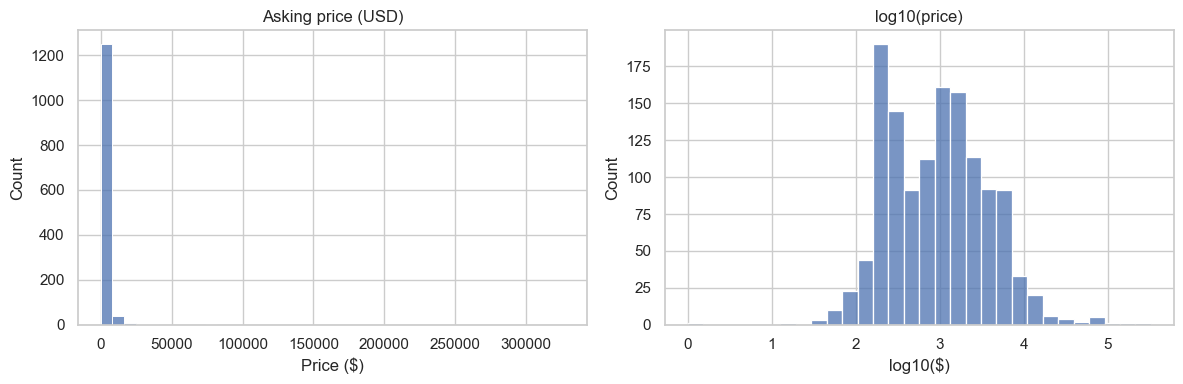

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["price"], bins=40, ax=axes[0])
axes[0].set_title("Asking price (USD)")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log10(clean["price"].clip(lower=1)), bins=30, ax=axes[1])
axes[1].set_title("log10(price)")
axes[1].set_xlabel("log10($)")
plt.tight_layout()
plt.show()


Most listings sit under a few thousand dollars, then there's a long tail of Cartier high jewelry. A $327k necklace will wreck a regular MAE if I leave it in.


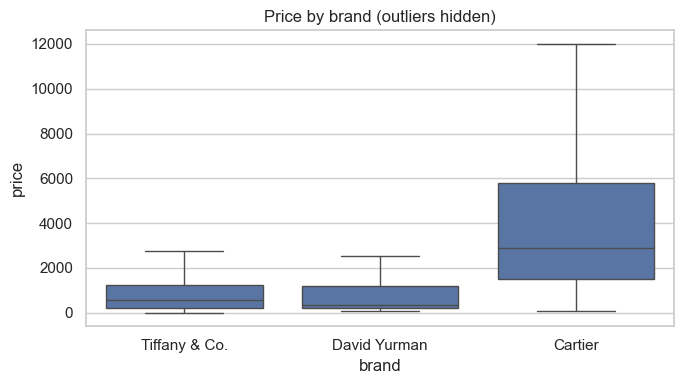

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=clean, x="brand", y="price", ax=ax, showfliers=False)
ax.set_title("Price by brand (outliers hidden)")
plt.tight_layout()
plt.show()


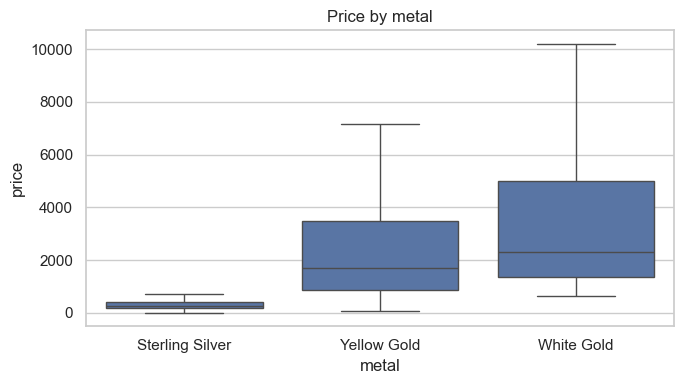

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ["Sterling Silver", "Yellow Gold", "White Gold"]
sns.boxplot(data=clean, x="metal", y="price", order=order, ax=ax, showfliers=False)
ax.set_title("Price by metal")
plt.tight_layout()
plt.show()


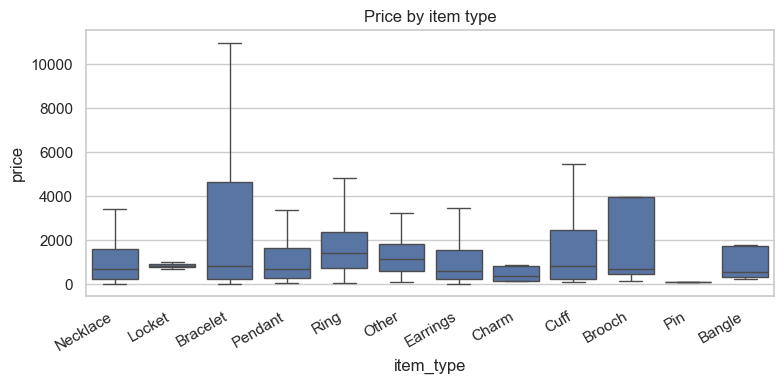

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=clean, x="item_type", y="price", ax=ax, showfliers=False)
ax.set_title("Price by item type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


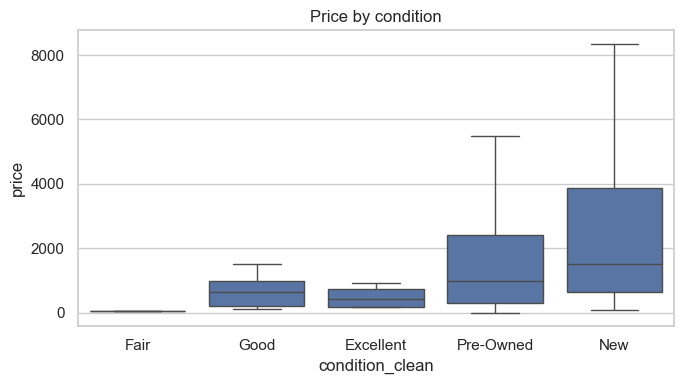

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=clean,
    x="condition_clean",
    y="price",
    order=["Fair", "Good", "Excellent", "Pre-Owned", "New"],
    ax=ax,
    showfliers=False,
)
ax.set_title("Price by condition")
plt.tight_layout()
plt.show()


Gold vs silver is the split you'd expect. Condition is almost useless right now because almost everything is lumped into Pre-Owned. Brand actually looks like the strongest categorical signal.


## Baseline models

There's enough data now for a regular train/test split. I'm dropping the really extreme prices (under $50 looks like auction starts / junk, over $20k is a handful of Cartier pieces that aren't comparable to a silver heart tag) and predicting `log1p(price)` so the tail doesn't dominate training. MAE below is on the original dollar scale.


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

model_df = clean[(clean["price"] >= 50) & (clean["price"] <= 20000)].copy()
print("rows used for modeling:", len(model_df), "(dropped", len(clean) - len(model_df), ")")

feature_cols = ["brand", "purity", "condition_clean", "item_type", "weight_grams"]
cat_features = ["brand", "purity", "condition_clean", "item_type"]
num_features = ["weight_grams"]

X = model_df[feature_cols]
y = model_df["price"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, ylog_train, ylog_test = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", SimpleImputer(strategy="median"), num_features),
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, ylog_train)
    pred = np.expm1(pipe.predict(X_test))
    pred = np.clip(pred, 0, None)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = {"pipe": pipe, "pred": pred, "MAE": mae, "R2": r2}
    print(f"{name:20s}  MAE=${mae:,.0f}   R2={r2:.3f}")

print(f"\nmedian price in the test set: ${y_test.median():,.0f}")


rows used for modeling: 1287 (dropped 22 )
Linear Regression     MAE=$1,069   R2=0.311
Random Forest         MAE=$988   R2=0.377

median price in the test set: $1,020


If MAE is in the same ballpark as the typical listing price, the model is only roughly ranking things (Cartier gold ring vs Tiffany silver charm) rather than nailing a specific resale number. That's about what I'd expect from title text + a coarse metal facet, with no weight or stone info for most rows.


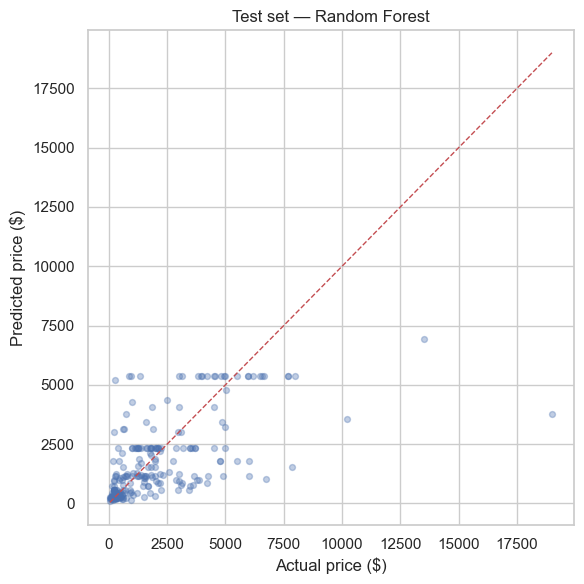

In [36]:
best_name = min(results, key=lambda n: results[n]["MAE"])
pred = results[best_name]["pred"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.35, s=18)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual price ($)")
ax.set_ylabel("Predicted price ($)")
ax.set_title(f"Test set — {best_name}")
plt.tight_layout()
plt.show()


## What the random forest actually uses

Fitted on the full modeling set, not the train split. Just to see which features it leaned on.


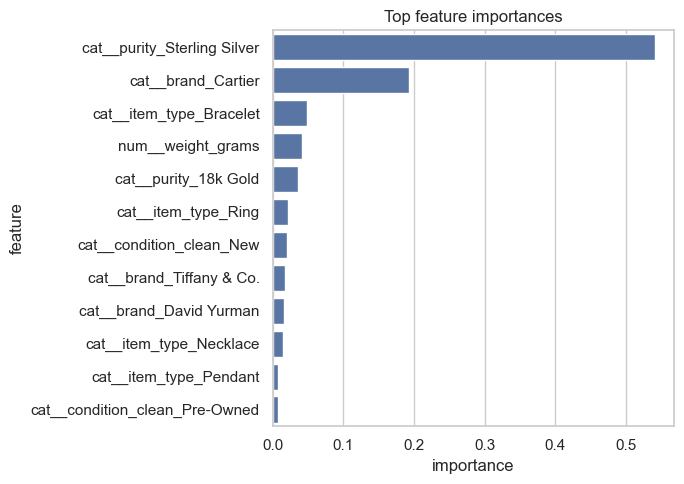

In [37]:
final_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
])
final_pipe.fit(X, y_log)

feature_names = final_pipe.named_steps["prep"].get_feature_names_out()
importances = final_pipe.named_steps["model"].feature_importances_
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=imp_df.head(12), x="importance", y="feature", ax=ax)
ax.set_title("Top feature importances")
plt.tight_layout()
plt.show()


## Save the cleaned table


In [38]:
clean.to_csv("../data/ebay_fine_jewelry_cleaned.csv", index=False)
clean.shape


(1309, 19)

## Conclusion

Overall, the results show that **brand**, **metal**, and **item type** are the strongest factors related to asking price in the current dataset. **Cartier** listings tend to be much **more expensive** than Tiffany & Co. and David Yurman, **while gold** pieces are generally **priced higher** than sterling silver and rings have the highest median price among item types. However, the dataset is still missing several features that would likely be important for accurately predicting jewelry prices. Most listings only have a general "Pre-Owned" condition, weight is rarely included, and item-specific information such as purity and stone details is mostly missing. The Random Forest model had an MAE of about $988, which is large compared to the median listing price, showing that the model can identify broad pricing patterns but cannot make precise price estimates yet. Overall, this model works as a good proof of concept, but collecting more detailed listing information and eventually using sold prices instead of asking prices would be important for building a more accurate jewelry price predictor.

## Next

- Scrape more brands.
- Hit actual item pages so weight / purity / stones aren't missing for every row.
- Condition from the search page is too vague to be useful. Need the item-page version.
- Try a gradient boosted model once the features aren't this thin.
- A couple of listings are $0.99 which is almost certainly an auction start, not a real price. Filter those more carefully.
